
# MLOps Screen Time Prediction Pipeline with Apache Airflow

**Portfolio Project — Machine Learning + MLOps**

This project builds a reproducible machine-learning pipeline to predict **mobile app usage in minutes** and then shows how the workflow can be automated with **Apache Airflow**.

The project is inspired by Aman Kharwal's *MLOps Pipeline using Apache Airflow* article, but the implementation is redesigned with:

- clear data validation,
- safer feature engineering,
- date-aware train/test splitting,
- a reusable `scikit-learn` pipeline,
- multiple evaluation metrics,
- persisted model artifacts,
- and a modern Airflow TaskFlow DAG.

**Source inspiration:** https://amanxai.com/2025/01/20/mlops-pipeline-using-apache-airflow/



## 1. Project Objective

We want to predict the target variable:

**`Usage (minutes)`**

using information about:

- the application,
- notifications,
- how often the app was opened,
- and calendar-based features.

The ML model is only one part of the project. The broader goal is to demonstrate a simple **MLOps workflow**:

**Data → Validation → Feature Engineering → Training → Evaluation → Artifacts → Airflow Automation**



## 2. Data Overview

### Data Dictionary

| Column | Meaning |
|---|---|
| `Date` | Observation date |
| `App` | Mobile application |
| `Usage (minutes)` | App usage in minutes — **target variable** |
| `Notifications` | Number of notifications |
| `Times Opened` | Number of times the app was opened |


In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

pd.set_option("display.max_columns", None)


In [3]:

# Find the dataset whether the notebook is started from the repo root
# or directly from the notebooks folder.
possible_paths = [
    Path("../data/raw/screentime_analysis.csv"),
    Path("data/raw/screentime_analysis.csv"),
    Path("screentime_analysis.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("screentime_analysis.csv could not be found.")

df = pd.read_csv(DATA_PATH)
df.head()


,Date,App,Usage (minutes),Notifications,Times Opened
0,2024-08-07,Instagram,81,24,57
1,2024-08-08,Instagram,90,30,53
2,2024-08-26,Instagram,112,33,17
3,2024-08-22,Instagram,82,11,38
4,2024-08-12,Instagram,59,47,16


In [4]:

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nExact duplicate rows:", df.duplicated().sum())


Shape: (200, 5)

Data types:
Date                 str
App                  str
Usage (minutes)    int64
Notifications      int64
Times Opened       int64
dtype: object

Missing values:
Date               0
App                0
Usage (minutes)    0
Notifications      0
Times Opened       0
dtype: int64

Exact duplicate rows: 0



### Data-quality observation

The dataset has no missing values and no exact duplicate rows.

However, the same **`Date + App`** combination can occur more than once. This matters for feature engineering: a simple row-based `shift(1)` would not reliably mean "previous calendar day for the same app."

For that reason, this version does **not** create a naive previous-day usage feature. This avoids introducing a misleading lag variable.


In [5]:

df["Date"] = pd.to_datetime(df["Date"])

print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Unique dates:", df["Date"].nunique())
print("Unique apps:", df["App"].nunique())
print("Repeated Date + App combinations:", df.duplicated(["Date", "App"]).sum())

df["App"].value_counts()


Date range: 2024-08-01 to 2024-08-30
Unique dates: 30
Unique apps: 8
Repeated Date + App combinations: 64


App
Instagram      25
X              25
WhatsApp       25
8 Ball Pool    25
Safari         25
Netflix        25
Facebook       25
LinkedIn       25
Name: count, dtype: int64


## 3. Exploratory Data Analysis

We first look at the target distribution and basic relationships before building the model.


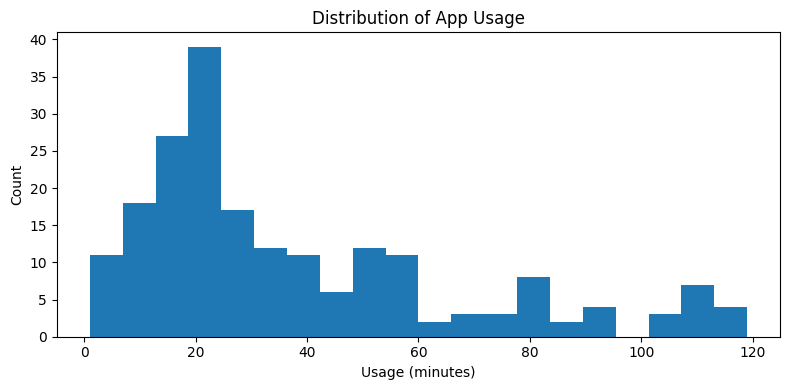

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df["Usage (minutes)"], bins=20)
plt.title("Distribution of App Usage")
plt.xlabel("Usage (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


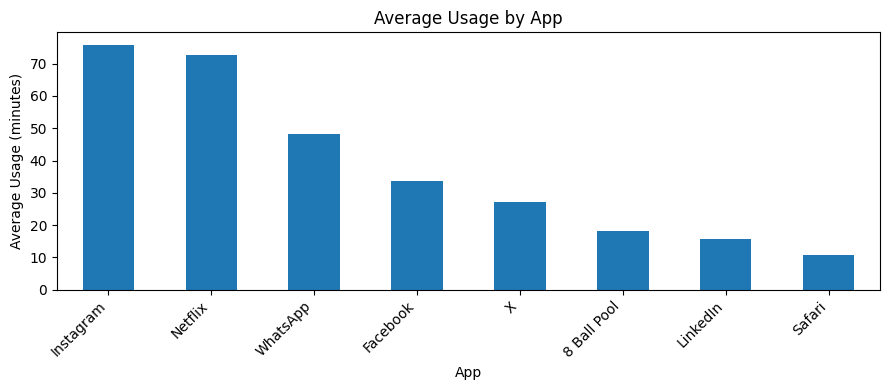

In [7]:

app_usage = (
    df.groupby("App")["Usage (minutes)"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 4))
app_usage.plot(kind="bar")
plt.title("Average Usage by App")
plt.xlabel("App")
plt.ylabel("Average Usage (minutes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


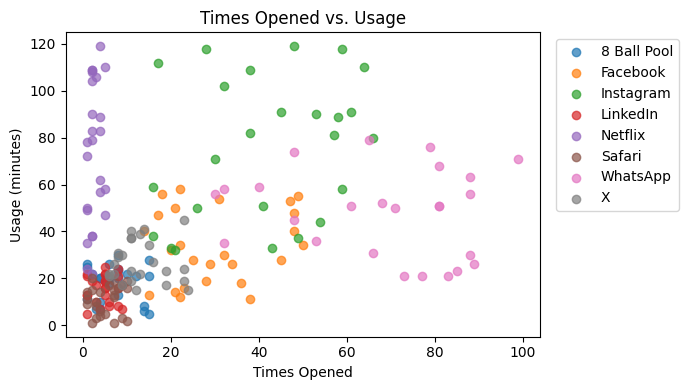

In [8]:
plt.figure(figsize=(7, 4))

for app, subset in df.groupby("App"):
    plt.scatter(
        subset["Times Opened"],
        subset["Usage (minutes)"],
        label=app,
        alpha=0.7
    )

plt.title("Times Opened vs. Usage")
plt.xlabel("Times Opened")
plt.ylabel("Usage (minutes)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [9]:

df[["Usage (minutes)", "Notifications", "Times Opened"]].corr().round(3)


,Usage (minutes),Notifications,Times Opened
Usage (minutes),1.000,0.276,0.324
Notifications,0.276,1.000,0.802
Times Opened,0.324,0.802,1.000



## 4. Feature Engineering

We create simple, explainable features that can also be reproduced later in production:

- `DayOfWeek`
- `DayOfMonth`
- `IsWeekend`
- `Notifications_x_TimesOpened`

The original `Date` column is kept for the train/test strategy but is not sent directly to the model.


In [10]:

data = df.copy()
data = data.sort_values(["Date", "App"]).reset_index(drop=True)

data["DayOfWeek"] = data["Date"].dt.dayofweek
data["DayOfMonth"] = data["Date"].dt.day
data["IsWeekend"] = (data["DayOfWeek"] >= 5).astype(int)

data["Notifications_x_TimesOpened"] = (
    data["Notifications"] * data["Times Opened"]
)

data.head()


,Date,App,Usage (minutes),Notifications,Times Opened,DayOfWeek,DayOfMonth,IsWeekend,Notifications_x_TimesOpened
0,2024-08-01,8 Ball Pool,8,1,14,3,1,0,14
1,2024-08-01,8 Ball Pool,20,3,6,3,1,0,18
2,2024-08-01,8 Ball Pool,19,1,5,3,1,0,5
3,2024-08-01,LinkedIn,10,6,6,3,1,0,36
4,2024-08-01,Netflix,108,0,2,3,1,0,0



## 5. Train/Test Strategy

A normal random row split can place observations from the same date in both training and test data.

For a more realistic MLOps scenario, we use **`GroupShuffleSplit` with `Date` as the group**.  
This means a date belongs either to training or to test — never both.

The test set therefore represents **unseen days**.


In [11]:

features = [
    "App",
    "Notifications",
    "Times Opened",
    "DayOfWeek",
    "DayOfMonth",
    "IsWeekend",
    "Notifications_x_TimesOpened",
]

target = "Usage (minutes)"

X = data[features]
y = data[target]
groups = data["Date"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train dates:", data.iloc[train_idx]["Date"].nunique())
print("Test dates:", data.iloc[test_idx]["Date"].nunique())


Training rows: 160
Test rows: 40
Train dates: 24
Test dates: 6



## 6. Preprocessing Pipeline

We use the same preprocessing logic every time the model is trained or later used for prediction.

### Numerical features
`MinMaxScaler`

### Categorical feature
`OneHotEncoder(handle_unknown="ignore")`

`handle_unknown="ignore"` is useful in production because a future dataset may contain a category that was not present during training.


In [12]:

numeric_features = [
    "Notifications",
    "Times Opened",
    "DayOfWeek",
    "DayOfMonth",
    "IsWeekend",
    "Notifications_x_TimesOpened",
]

categorical_features = ["App"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
    ]
)



## 7. Baseline Model

Before evaluating the Random Forest, we create a very simple reference model that always predicts the mean usage.

A production model should perform better than such a naive baseline.


In [13]:

baseline = DummyRegressor(strategy="mean")
baseline.fit(np.zeros((len(y_train), 1)), y_train)

baseline_predictions = baseline.predict(
    np.zeros((len(y_test), 1))
)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline MAE:  {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²:   {baseline_r2:.3f}")


Baseline MAE:  21.93
Baseline RMSE: 27.87
Baseline R²:   -0.055



## 8. Model Training — Random Forest Regressor

Random Forest is a good choice for this project because it:

- works well on small tabular datasets,
- captures nonlinear relationships,
- is easy to train,
- and is strong enough to demonstrate the MLOps workflow without unnecessary model complexity.


In [14]:

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        ),
    ]
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)



## 9. Model Evaluation


In [15]:

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

results = pd.DataFrame({
    "Model": ["Mean Baseline", "Random Forest"],
    "MAE": [baseline_mae, mae],
    "RMSE": [baseline_rmse, rmse],
    "R2": [baseline_r2, r2],
})

results.round(3)


,Model,MAE,RMSE,R2
0,Mean Baseline,21.926,27.874,-0.055
1,Random Forest,16.838,21.479,0.373


In [16]:

improvement = (baseline_mae - mae) / baseline_mae * 100

print(f"Random Forest MAE: {mae:.2f} minutes")
print(f"Random Forest RMSE: {rmse:.2f} minutes")
print(f"Random Forest R²: {r2:.3f}")
print(f"MAE improvement vs baseline: {improvement:.1f}%")


Random Forest MAE: 16.84 minutes
Random Forest RMSE: 21.48 minutes
Random Forest R²: 0.373
MAE improvement vs baseline: 23.2%


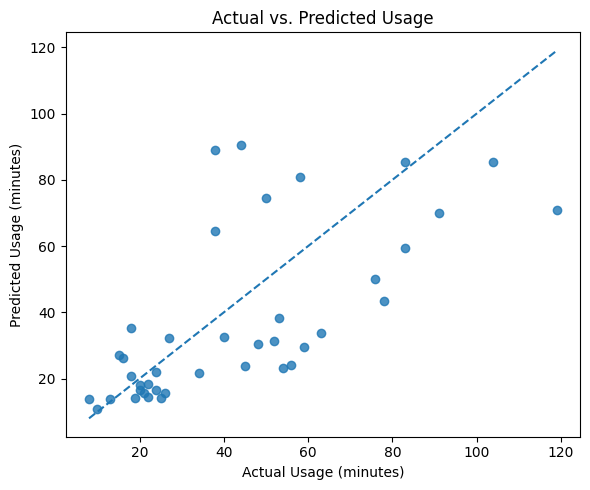

In [17]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

plt.figure(figsize=(6, 5))
plt.scatter(
    prediction_results["Actual"],
    prediction_results["Predicted"],
    alpha=0.8
)

min_value = min(
    prediction_results["Actual"].min(),
    prediction_results["Predicted"].min()
)
max_value = max(
    prediction_results["Actual"].max(),
    prediction_results["Predicted"].max()
)

plt.plot([min_value, max_value], [min_value, max_value], "--")
plt.title("Actual vs. Predicted Usage")
plt.xlabel("Actual Usage (minutes)")
plt.ylabel("Predicted Usage (minutes)")
plt.tight_layout()
plt.show()



## 10. Feature Importance

Random Forest can provide a simple view of which transformed features contribute most strongly to the model.


In [18]:

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importances = model.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
    .head(12)
)

feature_importance


,Feature,Importance
8,cat__App_Instagram,0.299961
10,cat__App_Netflix,0.266294
5,num__Notifications_x_TimesOpened,0.130749
0,num__Notifications,0.102610
1,num__Times Opened,0.073523
3,num__DayOfMonth,0.060781
2,num__DayOfWeek,0.046709
12,cat__App_WhatsApp,0.006738
4,num__IsWeekend,0.005640
11,cat__App_Safari,0.001885


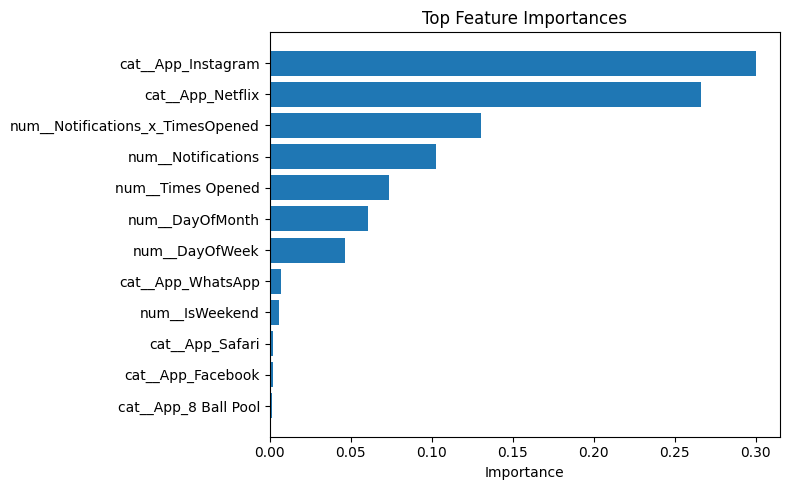

In [19]:
plot_data = feature_importance.sort_values("Importance")

plt.figure(figsize=(8, 5))
plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



## 11. Save Model Artifacts

In MLOps, a trained model should not exist only in notebook memory.

We save:

- the complete preprocessing + model pipeline,
- evaluation metrics,
- and test predictions.

Because preprocessing and the model are saved together in one `Pipeline`, future predictions use exactly the same transformations as training.


In [20]:

# Resolve repository root
if Path("../artifacts").exists():
    ARTIFACT_DIR = Path("../artifacts")
elif Path("artifacts").exists():
    ARTIFACT_DIR = Path("artifacts")
else:
    ARTIFACT_DIR = Path("artifacts")
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    model,
    ARTIFACT_DIR / "screentime_random_forest.joblib"
)

metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2),
    "baseline_MAE": float(baseline_mae),
    "MAE_improvement_percent": float(improvement),
}

with open(
    ARTIFACT_DIR / "metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metrics, f, indent=2)

prediction_results.to_csv(
    ARTIFACT_DIR / "test_predictions.csv",
    index=False
)

print("Artifacts saved to:", ARTIFACT_DIR.resolve())


Artifacts saved to: C:\Users\Ferides\Documents\13 - Yapay_Zeka_Ai\Specialize\MLOps_Screentime_Prediction\artifacts



## 12. MLOps Automation with Apache Airflow

The notebook demonstrates the ML logic interactively.

The repository also contains a separate Airflow DAG:

`dags/screentime_mlops_dag.py`

The automated workflow is:

```text
validate_raw_data
        ↓
prepare_features
        ↓
train_model
        ↓
report_metrics
```

The DAG uses the modern **Airflow TaskFlow API** and imports the reusable training logic from `src/train_pipeline.py`.

This separation is important:

- **Notebook** → exploration, explanation, learning
- **src/** → reusable production logic
- **Airflow DAG** → orchestration and scheduling



## 13. Summary

This project created an end-to-end machine-learning workflow for screen-time prediction.

### What was implemented

- data loading and validation,
- exploratory data analysis,
- feature engineering,
- date-aware train/test splitting,
- reusable preprocessing with `ColumnTransformer`,
- Random Forest regression,
- baseline comparison,
- MAE, RMSE and R² evaluation,
- model artifact persistence,
- and an Apache Airflow MLOps DAG.

### Main methodological improvement

The dataset contains repeated `Date + App` combinations. Therefore, using a simple row-level `shift(1)` as "previous-day usage" would not reliably represent the previous calendar day. The project avoids this ambiguity and instead uses transparent calendar and behavioral features.

### MLOps perspective

The current version is a **training and orchestration pipeline**, not a complete production platform. A next version could add:

- MLflow for experiment tracking and model registry,
- Docker,
- FastAPI deployment,
- GitHub Actions CI/CD,
- automated testing,
- and data/model drift monitoring.

This keeps Version 1 understandable while still demonstrating a professional MLOps architecture.
